In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading historical trader data
trades = pd.read_csv("historical_data.csv")

# Loadong fear & greed index data
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [5]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [10]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
# coverting the tarder timestamp

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")

In [12]:
trades['Timestamp IST']

0        2024-12-02 22:50:00
1        2024-12-02 22:50:00
2        2024-12-02 22:50:00
3        2024-12-02 22:50:00
4        2024-12-02 22:50:00
                 ...        
211219   2025-04-25 15:35:00
211220   2025-04-25 15:35:00
211221   2025-04-25 15:35:00
211222   2025-04-25 15:35:00
211223   2025-04-25 15:35:00
Name: Timestamp IST, Length: 211224, dtype: datetime64[ns]

In [13]:
# Extacting only the date

trades['date'] = trades['Timestamp IST'].dt.date

In [14]:
# Converting Sentiment Date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [15]:
sentiment['date']

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object

In [16]:
# Merging Both Datasets
merged_df = pd.merge(
    trades,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

In [17]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [18]:
merged_df.shape

(211224, 19)

In [19]:
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      6
value               6
dtype: int64

In [20]:
merged_df[merged_df.isnull().any(axis=1)]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745eb...,40671411386,False,2.719680,8.350000e+13,1.730000e+12,2024-10-26,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671438761,False,2.810115,3.230000e+14,1.730000e+12,2024-10-26,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,1.716957,1.070000e+15,1.730000e+12,2024-10-26,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.131570,8.770000e+14,1.730000e+12,2024-10-26,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.009605,9.820000e+14,1.730000e+12,2024-10-26,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd4...,40671466136,False,1.124277,9.360000e+14,1.730000e+12,2024-10-26,NaN,NaN


In [21]:
merged_df[merged_df['Coin'] == 'EIGEN'].shape[0]

330

In [22]:
merged_df = merged_df.dropna(subset=['classification', 'value'])

In [23]:
merged_df[['classification', 'value']].isnull().sum()

classification    0
value             0
dtype: int64

In [24]:
merged_df.shape

(211218, 19)

In [25]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724569344,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,21.012784


In [26]:
#Trade Count by Sentiment
merged_df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

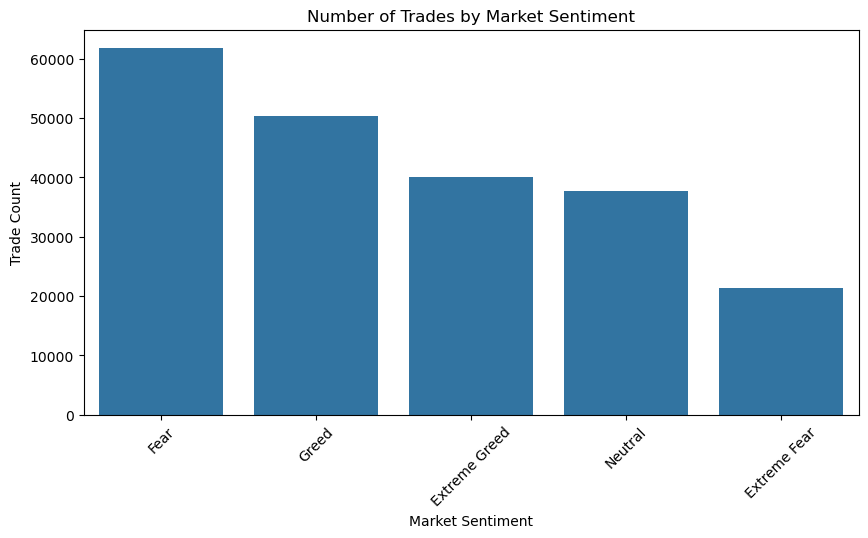

In [27]:
# Visualization: Trade Count by Sentiment

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")

plt.xticks(rotation=45)

plt.show()

# --> Profitability Analysis

In [28]:
# Total Profit by Sentiment
merged_df.groupby('classification')['Closed PnL'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

In [29]:
# Average Profit by Sentiment
merged_df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [30]:
# Median Profit by Sentiment
merged_df.groupby('classification')['Closed PnL'].median()

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64

In [31]:
# Creating  Summary Table
sentiment_summary = merged_df.groupby('classification')['Closed PnL'].agg(
    Total_PnL='sum',
    Average_PnL='mean',
    Median_PnL='median',
    Max_PnL='max',
    Min_PnL='min'
)

sentiment_summary

,Total_PnL,Average_PnL,Median_PnL,Max_PnL,Min_PnL
classification,,,,,
Extreme Fear,7.391102e+05,34.537862,0.0,115287.00000,-31036.69194
Extreme Greed,2.715171e+06,67.892861,0.0,44223.45187,-10259.46800
Fear,3.357155e+06,54.290400,0.0,135329.09010,-35681.74723
Greed,2.150129e+06,42.743559,0.0,74530.52371,-117990.10410
Neutral,1.292921e+06,34.307718,0.0,48504.09555,-24500.00000


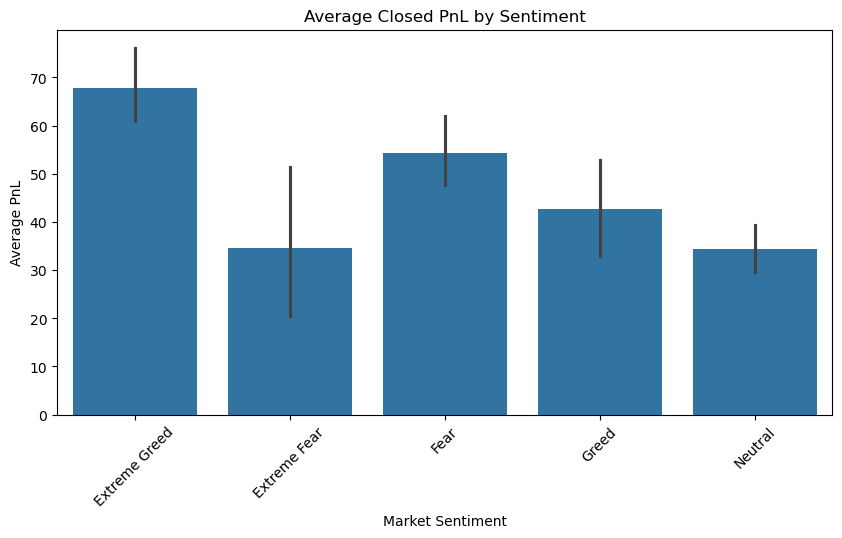

In [32]:
# Visualization: Average PnL by Sentiment

plt.figure(figsize=(10,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    estimator=np.mean
)

plt.title("Average Closed PnL by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.xticks(rotation=45)

plt.show()

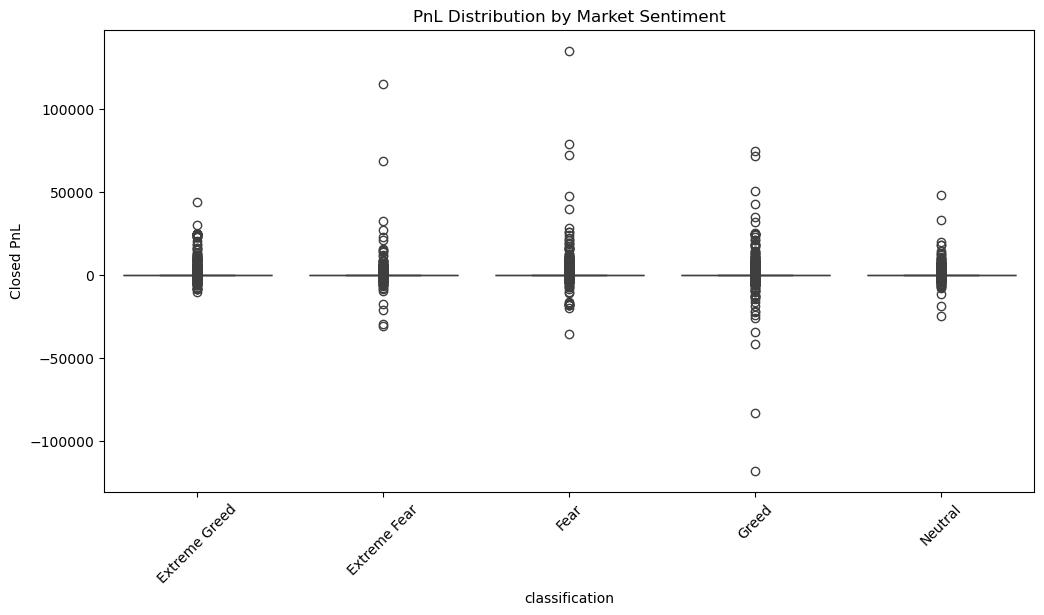

In [33]:
# Boxplot of PnL
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")

plt.xticks(rotation=45)

plt.show()

#--> Trading Volume Analysis

In [34]:
# Total Volume by Sentiment
merged_df.groupby('classification')['Size USD'].sum()

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64

In [35]:
# Average Trade Size
merged_df.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

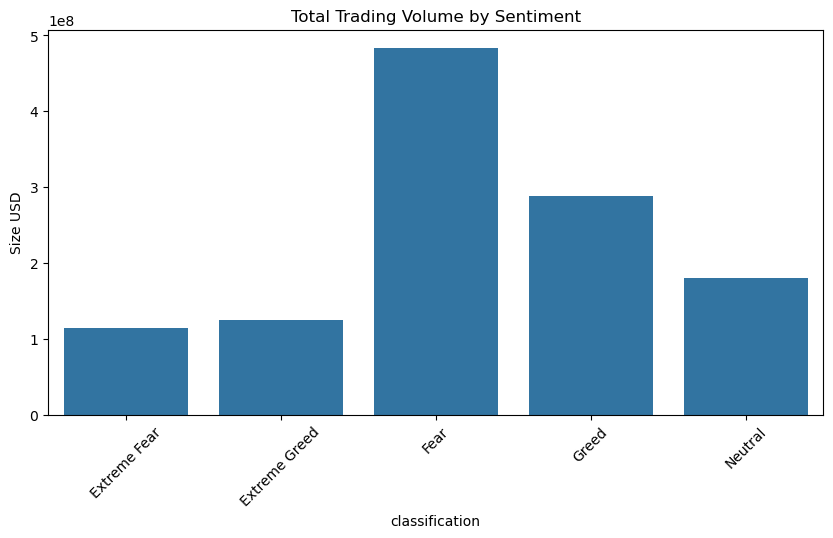

In [36]:
# Visualization: Trading Volume

volume_data = merged_df.groupby('classification')['Size USD'].sum().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=volume_data,
    x='classification',
    y='Size USD'
)

plt.title("Total Trading Volume by Sentiment")

plt.xticks(rotation=45)

plt.show()

# --> Long vs Short Analysis

In [37]:
merged_df['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

In [38]:
#Average Profit by Side
merged_df.groupby('Side')['Closed PnL'].mean()

Side
BUY     35.693245
SELL    60.713803
Name: Closed PnL, dtype: float64

In [39]:
# Side vs Sentiment
side_sentiment = merged_df.groupby(['classification', 'Side'])['Closed PnL'].mean().reset_index()

side_sentiment

,classification,Side,Closed PnL
0,Extreme Fear,BUY,34.114627
1,Extreme Fear,SELL,34.980106
2,Extreme Greed,BUY,10.498927
3,Extreme Greed,SELL,114.584643
4,Fear,BUY,63.927104
5,Fear,SELL,45.049641
6,Greed,BUY,25.002302
7,Greed,SELL,59.691091
8,Neutral,BUY,29.227429
9,Neutral,SELL,39.456408


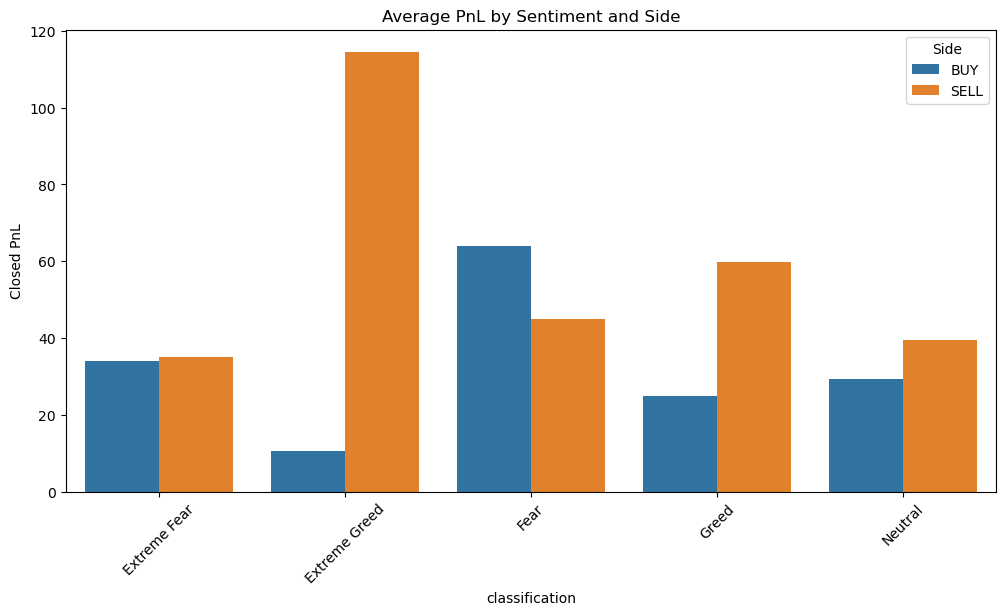

In [40]:
# Visualization: Side vs Profitability

plt.figure(figsize=(12,6))

sns.barplot(
    data=side_sentiment,

    x='classification',

    y='Closed PnL',
    hue='Side'
)

plt.title("Average PnL by Sentiment and Side")

plt.xticks(rotation=45)

plt.show()

In [41]:
# Top Profitable Traders
top_traders = merged_df.groupby('Account')['Closed PnL'].sum()

top_traders = top_traders.sort_values(ascending=False)

top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

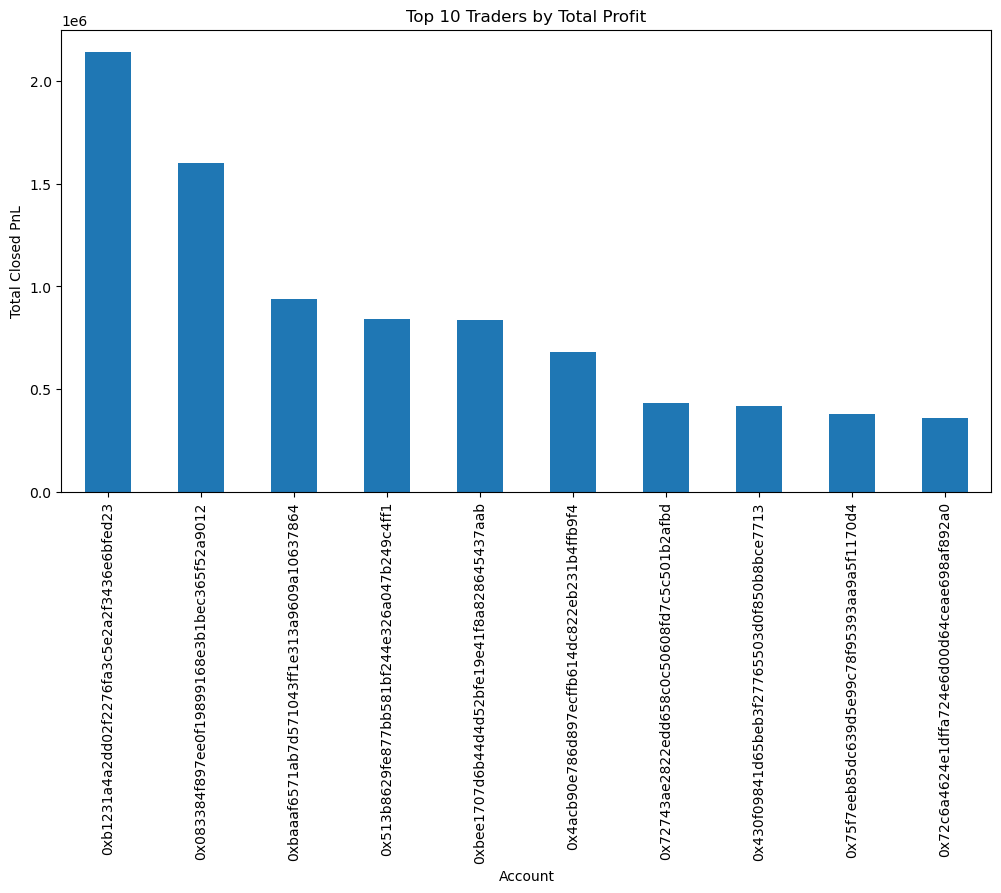

In [42]:
# Visualization: Top Traders

top10 = top_traders.head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title("Top 10 Traders by Total Profit")
plt.ylabel("Total Closed PnL")

plt.show()

In [43]:
# Daily Profit Trend
daily_pnl = merged_df.groupby('date')['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [44]:
daily_pnl

,date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000
...,...,...
474,2025-04-27,2702.067468
475,2025-04-28,36906.813759
476,2025-04-29,125749.613427
477,2025-04-30,14003.797269


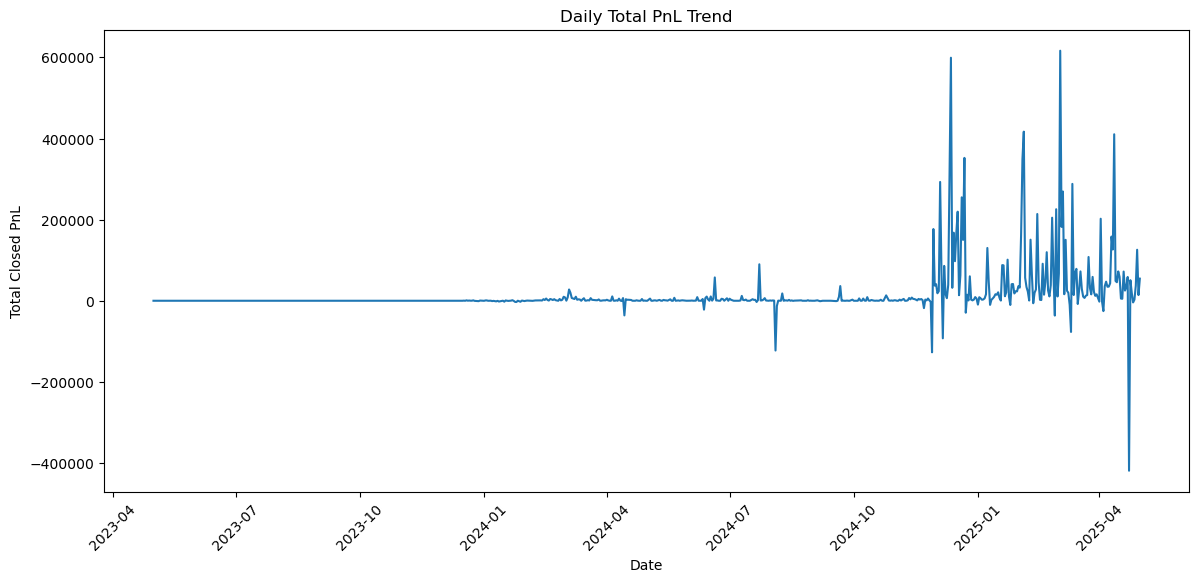

In [45]:
# Visualization: Daily Profit Trend
plt.figure(figsize=(14,6))

plt.plot(
    daily_pnl['date'],
    daily_pnl['Closed PnL']
)

plt.title("Daily Total PnL Trend")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [46]:
# Correlation Analysis
numeric_cols = merged_df.select_dtypes(include=np.number)

correlation = numeric_cols.corr()

correlation

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
Execution Price,1.000000,-0.017185,0.189859,0.017242,-0.006429,0.125838,0.225266,0.001846,0.130706,-0.027558
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005067,-0.043754,0.006710,-0.003847,-0.040949,0.023080
Size USD,0.189859,0.013310,1.000000,0.007787,0.123645,0.045223,0.745940,0.000250,0.039762,-0.029843
Start Position,0.017242,0.044660,0.007787,1.000000,0.004068,-0.082801,0.010559,0.001164,-0.105488,-0.049619
Closed PnL,-0.006429,0.005067,0.123645,0.004068,1.000000,-0.006916,0.084094,0.003493,-0.009564,0.008121
Order ID,0.125838,-0.043754,0.045223,-0.082801,-0.006916,1.000000,0.039307,0.003901,0.929169,-0.561758
Fee,0.225266,0.006710,0.745940,0.010559,0.084094,0.039307,1.000000,0.000944,0.036890,-0.026877
Trade ID,0.001846,-0.003847,0.000250,0.001164,0.003493,0.003901,0.000944,1.000000,0.002361,-0.006574
Timestamp,0.130706,-0.040949,0.039762,-0.105488,-0.009564,0.929169,0.036890,0.002361,1.000000,-0.377565
value,-0.027558,0.023080,-0.029843,-0.049619,0.008121,-0.561758,-0.026877,-0.006574,-0.377565,1.000000


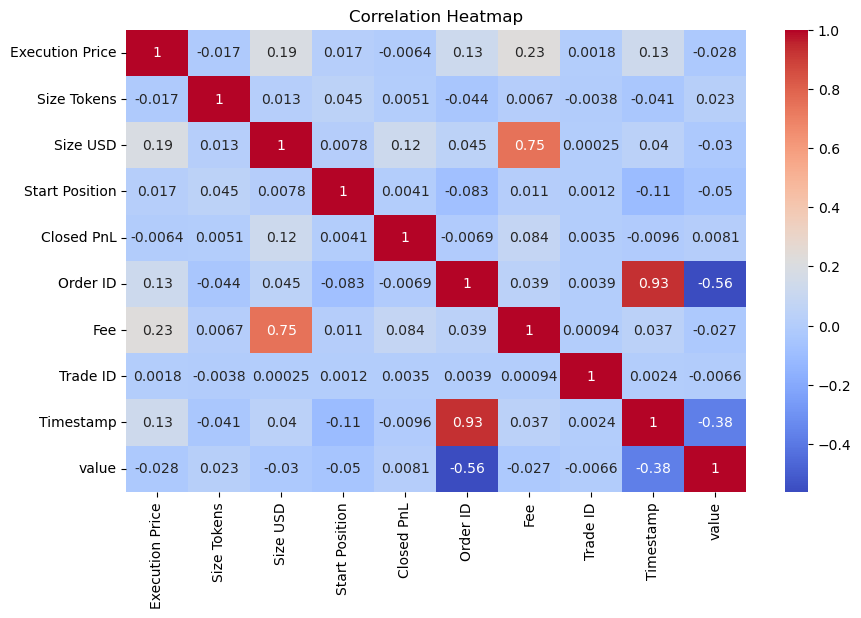

In [47]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Key Insights:

1. Fear and Extreme Greed periods showed higher profitability.
2. Trading volume increases during emotional market conditions.
3. Certain trading sides perform better under specific sentiments.
4. Market sentiment strongly affects trader behavior.


# --> Creating Better Features

In [48]:
# Converting Sentiment into Numbers
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

merged_df['sentiment_score'] = merged_df['classification'].map(sentiment_map)

In [49]:
# Creating Profit/Loss Label
merged_df['is_profit'] = np.where(
    merged_df['Closed PnL'] > 0,
    1,
    0
)

In [50]:
# Win Rate by Sentiment
win_rate = merged_df.groupby('classification')['is_profit'].mean() * 100

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64

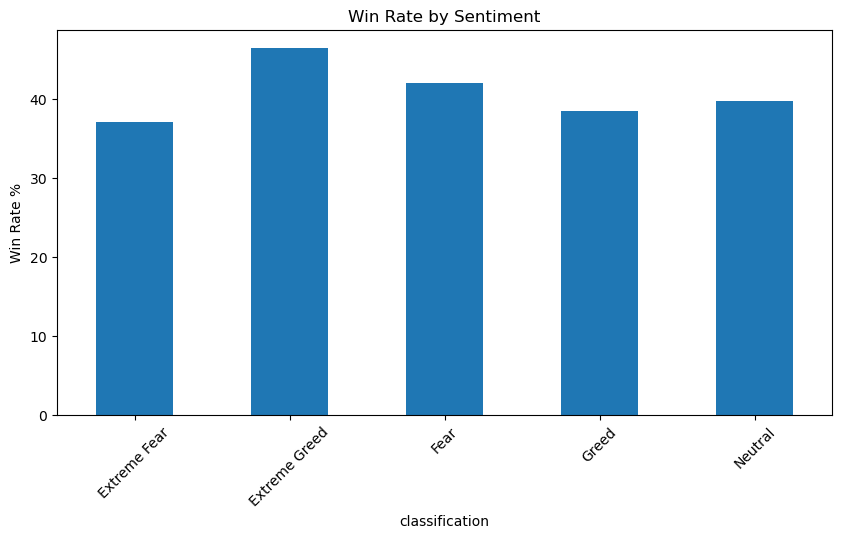

In [51]:
# Visualization
plt.figure(figsize=(10,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate %")

plt.xticks(rotation=45)

plt.show()

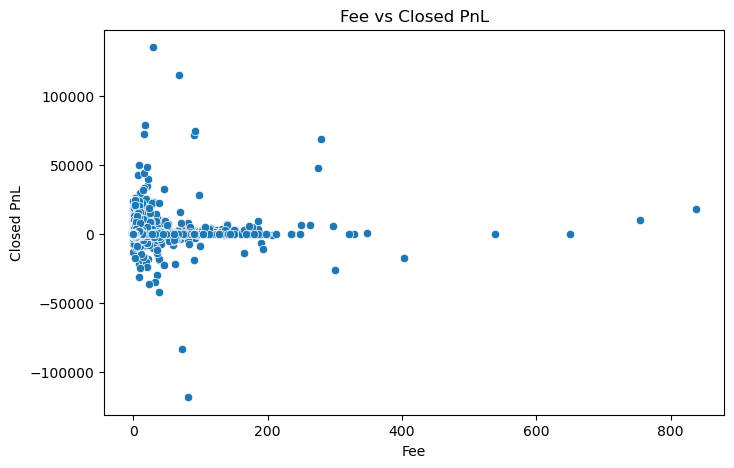

In [52]:
# Fee vs Profitability

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_df,
    x='Fee',
    y='Closed PnL'
)

plt.title("Fee vs Closed PnL")

plt.show()

In [53]:
# Direction Analysis
merged_df.groupby('Direction')['Closed PnL'].mean()

Direction
Auto-Deleveraging             7184.807003
Buy                              0.000000
Close Long                      74.426422
Close Short                    101.850421
Liquidated Isolated Short   -12752.913040
Long > Short                    34.936474
Open Long                        0.000000
Open Short                       0.000000
Sell                           146.053081
Settlement                     -29.215368
Short > Long                   154.190415
Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64

In [54]:
#Coin-wise Analysis

# Most Traded Coins
merged_df['Coin'].value_counts().head(10)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

In [55]:
# Profitability by Coin
coin_profit = merged_df.groupby('Coin')['Closed PnL'].sum()

coin_profit.sort_values(ascending=False).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

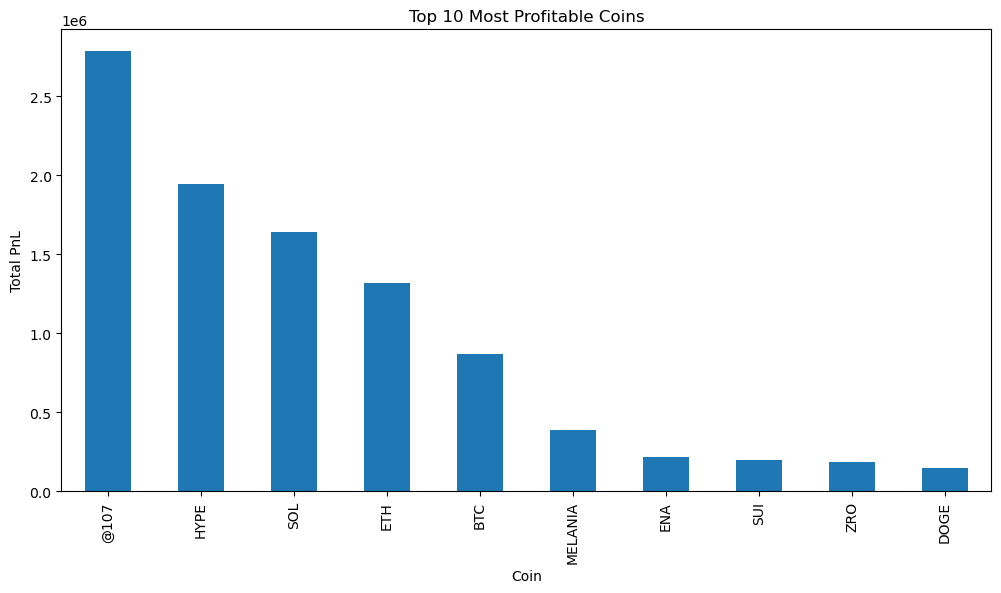

In [56]:
# Visualization

top_coins = coin_profit.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_coins.plot(kind='bar')

plt.title("Top 10 Most Profitable Coins")

plt.ylabel("Total PnL")

plt.show()

In [57]:
#Fear vs Greed Comparison
# Simplifing Categories
def market_phase(x):

    if x in ['Fear', 'Extreme Fear']:
        return 'Fear Market'

    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed Market'

    else:
        return 'Neutral Market'

merged_df['market_phase'] = merged_df['classification'].apply(market_phase)

In [58]:
# Comparing Profitability
merged_df.groupby('market_phase')['Closed PnL'].mean()

market_phase
Fear Market       49.212077
Greed Market      53.882281
Neutral Market    34.307718
Name: Closed PnL, dtype: float64

In [59]:
# Heatmap of Sentiment vs Side
pivot_table = merged_df.pivot_table(
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

pivot_table


Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


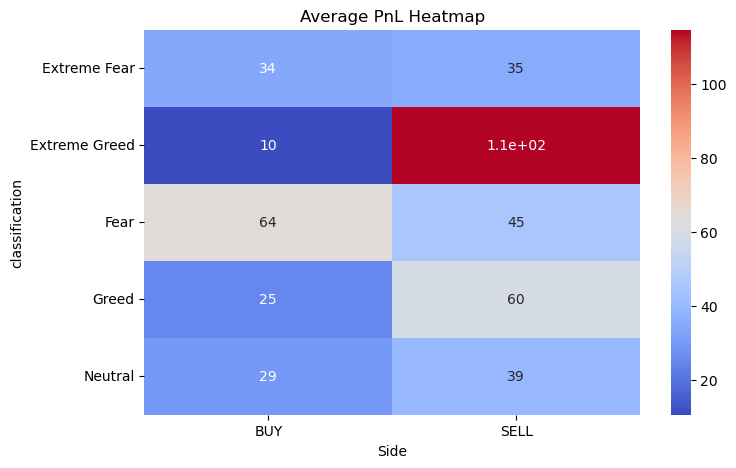

In [60]:
# Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='coolwarm'
)

plt.title("Average PnL Heatmap")

plt.show()


In [61]:
#Trader Ranking
trader_stats = merged_df.groupby('Account').agg({
    'Closed PnL': ['sum', 'mean'],
    'Account': 'count'
})

trader_stats.columns = ['total_pnl', 'avg_pnl', 'trade_count']

trader_stats.sort_values(
    by='total_pnl',
    ascending=False
).head(10)

,total_pnl,avg_pnl,trade_count
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,145.481748,14733
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,44.364091,21192
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,68.684419,12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,20.806305,40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,155.589314,4356
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,270.034947,1590
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1237
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,38.319560,9893


In [62]:
# Time-based Analysis
merged_df['hour'] = pd.to_datetime(
    merged_df['Timestamp IST']
).dt.hour

In [63]:
# Trading Activity by Hour
hourly_trades = merged_df.groupby('hour')['Closed PnL'].mean()

hourly_trades

hour
0      43.126269
1      49.918770
2      34.205399
3      43.711571
4      44.449555
5      40.460611
6      32.983412
7      83.026712
8      58.886420
9      44.979426
10     61.347489
11     76.863003
12    131.173707
13     52.382349
14     23.124431
15     58.562155
16     41.975938
17     34.481087
18     44.993427
19     55.861869
20     49.711340
21     31.169804
22     37.808613
23     18.753063
Name: Closed PnL, dtype: float64

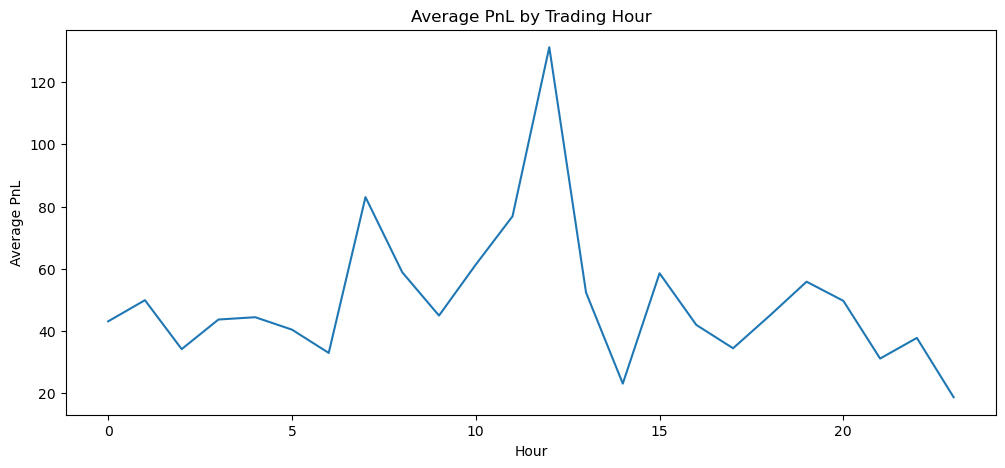

In [64]:
# Plot
plt.figure(figsize=(12,5))

hourly_trades.plot()

plt.title("Average PnL by Trading Hour")
plt.xlabel("Hour")
plt.ylabel("Average PnL")

plt.show()


In [65]:
# Selecting Features for  ml model
features = merged_df[
    ['sentiment_score', 'Size USD', 'Fee', 'Execution Price']
]

target = merged_df['is_profit']

In [66]:
from sklearn.model_selection import train_test_split

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [67]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# Prediction
predictions = model.predict(X_test)

In [69]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8510320992330271


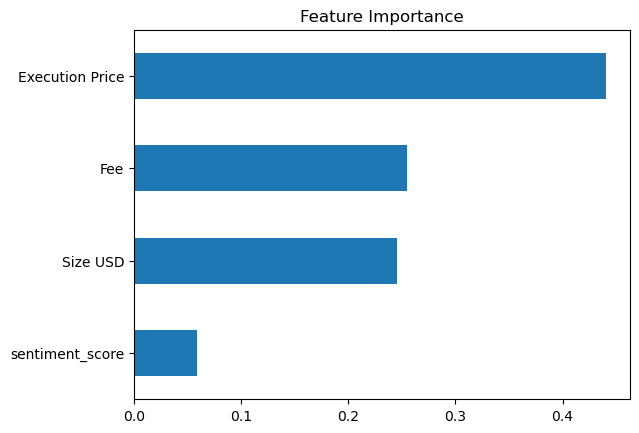

In [70]:
# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=features.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

Final Business Insights

1) Fear and Extreme Greed create higher trading opportunities.

2) Emotional market phases increase trader activity.

3) Certain coins consistently generate better profitability.

4) Trade timing impacts profitability.

5) Sentiment score influences trading success probability.

